**Thesis**: A Comparative Study of Large Language Models for Financial Sentiment Analysis and Their Predictive Potential for Short-Term Stock Price Movement

**Component: Experiment 1** - Model B : Meta Llama 3 (8B Instruct)

**Description:** This notebook evaluates Llama 3 8B on the Financial PhraseBank dataset under zero-shot conditions. It generates sentiment predictions and computes accuracy, precision, recall, F1-score (macro-averaged), and confusion matrix.

Select T4 GPU as runtime.

In [1]:
# Step 1 — Install bitsandbytes (restart required after this)

!pip install -q -U bitsandbytes accelerate

Go to runtime -> restart this session again -> then run cell 1 and run cell 2

In [2]:
# Import required libraries — Experiment 1b: Llama 3

import pandas as pd
import numpy as np
import torch
import warnings
import gc

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detected    : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU detected    : Tesla T4


Add the API Key from Hugging Face using "Add New Secret" in Google Colab

In [3]:
# Connect to Hugging Face and load Financial PhraseBank

from google.colab import userdata
from huggingface_hub import login, hf_hub_download

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Hugging Face login successful.")

# Load Financial PhraseBank — full dataset
file_path = hf_hub_download(
    repo_id="takala/financial_phrasebank",
    filename="sentences_50agree/train-00000-of-00001.parquet",
    repo_type="dataset",
    revision="0dd3028d70cbd18ded8887e65e83343b03a50482",
    token=hf_token
)

df_fpb = pd.read_parquet(file_path)

label_map = {0: "negative", 1: "neutral", 2: "positive"}
df_fpb["sentiment"] = df_fpb["label"].map(label_map)

true_labels = df_fpb["sentiment"].tolist()
texts = df_fpb["sentence"].tolist()

print(f"\nFinancial PhraseBank loaded.")
print(f"Total sentences : {len(df_fpb)}")
print(f"Label distribution:")
print(df_fpb["sentiment"].value_counts())

Hugging Face login successful.


sentences_50agree/train-00000-of-00001.p(…):   0%|          | 0.00/390k [00:00<?, ?B/s]


Financial PhraseBank loaded.
Total sentences : 4846
Label distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [4]:
# Load Llama 3 8B with 4-bit quantisation

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading Llama 3 8B...")

llama_tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Meta-Llama-3-8B-Instruct",
    token=hf_token
)

llama_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Meta-Llama-3-8B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token
)

print("Llama 3 8B loaded successfully.")

Loading Llama 3 8B...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Llama 3 8B loaded successfully.


In [5]:
# Define Llama 3 classifier and run on full dataset

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

def clean_label(label):
    label = label.strip().lower()
    if "positive" in label:
        return "positive"
    elif "negative" in label:
        return "negative"
    elif "neutral" in label:
        return "neutral"
    else:
        return "neutral"

def classify_llama3(text):
    messages = [
        {"role": "system", "content": "You are a financial sentiment classifier. Classify the sentiment as exactly one word: positive, negative, or neutral."},
        {"role": "user", "content": f"Classify the sentiment of this financial text:\n\n{text}\n\nRespond with only one word: positive, negative, or neutral."}
    ]

    tokenized = llama_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    ).to(llama_model.device)

    with torch.no_grad():
        outputs = llama_model.generate(
            **tokenized,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=llama_tokenizer.eos_token_id
        )

    input_length = tokenized["input_ids"].shape[1]
    generated = llama_tokenizer.decode(
        outputs[0][input_length:],
        skip_special_tokens=True
    )
    return clean_label(generated)

# Run on full dataset
llama3_preds = []
total = len(texts)

print(f"Running Llama 3 on {total} sentences...")

for i, text in enumerate(texts):
    label = classify_llama3(text)
    llama3_preds.append(label)

    if (i + 1) % 100 == 0:
        print(f"  Progress: {i+1}/{total}")

print(f"\nDone. Total predictions: {len(llama3_preds)}")
print(f"\nPrediction distribution:")
print(pd.Series(llama3_preds).value_counts())

Running Llama 3 on 4846 sentences...
  Progress: 100/4846
  Progress: 200/4846
  Progress: 300/4846
  Progress: 400/4846
  Progress: 500/4846
  Progress: 600/4846
  Progress: 700/4846
  Progress: 800/4846
  Progress: 900/4846
  Progress: 1000/4846
  Progress: 1100/4846
  Progress: 1200/4846
  Progress: 1300/4846
  Progress: 1400/4846
  Progress: 1500/4846
  Progress: 1600/4846
  Progress: 1700/4846
  Progress: 1800/4846
  Progress: 1900/4846
  Progress: 2000/4846
  Progress: 2100/4846
  Progress: 2200/4846
  Progress: 2300/4846
  Progress: 2400/4846
  Progress: 2500/4846
  Progress: 2600/4846
  Progress: 2700/4846
  Progress: 2800/4846
  Progress: 2900/4846
  Progress: 3000/4846
  Progress: 3100/4846
  Progress: 3200/4846
  Progress: 3300/4846
  Progress: 3400/4846
  Progress: 3500/4846
  Progress: 3600/4846
  Progress: 3700/4846
  Progress: 3800/4846
  Progress: 3900/4846
  Progress: 4000/4846
  Progress: 4100/4846
  Progress: 4200/4846
  Progress: 4300/4846
  Progress: 4400/4846
  Pr

In [6]:
# Evaluate Llama 3 performance on full dataset

labels_order = ["positive", "negative", "neutral"]

acc  = accuracy_score(true_labels, llama3_preds)
prec = precision_score(true_labels, llama3_preds, average="macro", labels=labels_order)
rec  = recall_score(true_labels, llama3_preds, average="macro", labels=labels_order)
f1   = f1_score(true_labels, llama3_preds, average="macro", labels=labels_order)

print("=" * 45)
print("Llama 3 8B — Experiment 1 Results")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(true_labels, llama3_preds, labels=labels_order))

Llama 3 8B — Experiment 1 Results
  Accuracy  : 0.7825  (78.25%)
  Precision : 0.7867
  Recall    : 0.7375
  F1-Score  : 0.7585

Detailed Classification Report:
              precision    recall  f1-score   support

    positive       0.74      0.63      0.68      1363
    negative       0.83      0.72      0.77       604
     neutral       0.79      0.87      0.83      2879

    accuracy                           0.78      4846
   macro avg       0.79      0.74      0.76      4846
weighted avg       0.78      0.78      0.78      4846



In [7]:
# Save Llama 3 results

llama3_scores = {
    "model": "Llama 3 8B",
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4)
}

df_fpb["llama3_pred"] = llama3_preds

print("Llama 3 8B — Results Summary")
print(pd.DataFrame([llama3_scores]))

Llama 3 8B — Results Summary
        model  accuracy  precision  recall  f1_score
0  Llama 3 8B    0.7825     0.7867  0.7375    0.7585


In [8]:
# Save Llama 3 predictions to Google Drive

from google.colab import drive
drive.mount("/content/drive")

import os
os.makedirs("/content/drive/MyDrive/Thesis_Data", exist_ok=True)

df_fpb.to_csv("/content/drive/MyDrive/Thesis_Data/exp1_llama3_preds.csv", index=False)

print("Llama 3 predictions saved to Google Drive.")

Mounted at /content/drive
Llama 3 predictions saved to Google Drive.


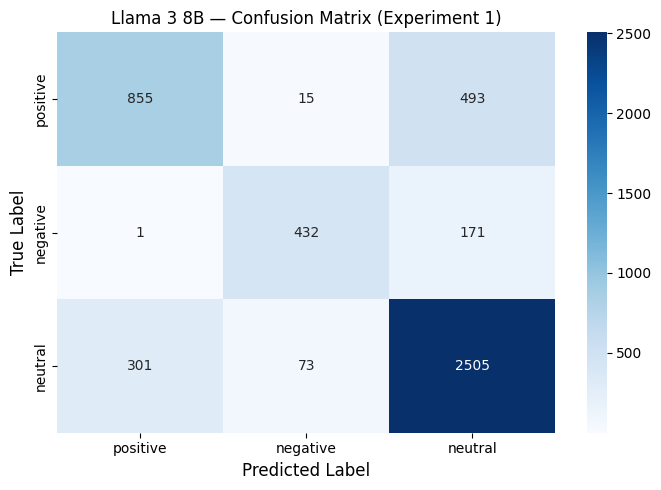

Confusion matrix saved to Google Drive.


In [9]:
# Confusion Matrix — Llama 3 8B Experiment 1

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_order = ["positive", "negative", "neutral"]

cm = confusion_matrix(true_labels, llama3_preds, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order,
            yticklabels=labels_order)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Llama 3 8B — Confusion Matrix (Experiment 1)", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Thesis_Data/fig_cm_llama3.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to Google Drive.")